In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

# pandas & numpy → data handling
# matplotlib & seaborn → visualization
# sklearn → ML models & metrics

In [2]:
# Load Iris dataset
data = pd.read_csv("iris.csv")

# Overview
print(data.head())
print(data.info())
print(data.describe())
print(data['species'].value_counts())

# Dataset has 150 samples, 4 numeric features, 3 species.
# Balanced dataset (50 samples each). No missing values.

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

       species  
0  Iris-setosa  
1  Iris-setosa  
2  Iris-setosa  
3  Iris-setosa  
4  Iris-setosa  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non

In [5]:
# Split features & target
X = data.drop('species', axis=1)
y = data['species']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 70% for training, 30% for testing
# random_state ensures reproducible results

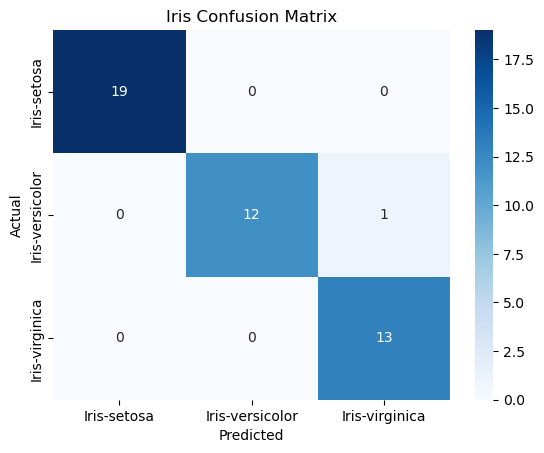

In [7]:
# Train Gaussian Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict test set
y_pred = nb.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nb.classes_, yticklabels=nb.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Iris Confusion Matrix")
plt.show()

# Diagonal → correct predictions (TP)
# Off-diagonal → misclassifications (FP / FN)

In [9]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

# Detailed report
print(classification_report(y_test, y_pred))

# Accuracy → overall correctness
# Precision → predicted positives that are correct
# Recall → actual positives correctly identified

Accuracy: 0.98
Precision: 0.98
Recall: 0.97
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.97      0.97        45
   weighted avg       0.98      0.98      0.98        45



In [11]:
# Cross-validation
cv_scores = cross_val_score(nb, X, y, cv=5)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.2f}")

# Ensures model performs consistently across multiple splits

CV Scores: [0.93333333 0.96666667 0.93333333 0.93333333 1.        ]
Mean CV Accuracy: 0.95


In [13]:
# Predict probabilities for first 5 test samples
print(nb.predict_proba(X_test[:5]))

# Shows confidence for each class

[[4.15880005e-088 9.95527834e-001 4.47216606e-003]
 [1.00000000e+000 1.31031235e-013 2.21772205e-020]
 [9.83170191e-285 2.70138564e-012 1.00000000e+000]
 [9.54745274e-092 9.74861431e-001 2.51385686e-002]
 [1.08679560e-103 8.31910700e-001 1.68089300e-001]]


In [15]:
# Import additional libraries for text classification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# MultinomialNB → works with discrete data (word counts)
# TF-IDF → converts text to numerical representation

In [17]:
# Load Spam dataset
data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['label', 'text', 'label_num']]  # Keep relevant columns

print(data.head())
print(data['label'].value_counts())

# 5171 messages, labeled as 'ham' (0) or 'spam' (1)

  label                                               text  label_num
0   ham  Subject: enron methanol ; meter # : 988291\r\n...          0
1   ham  Subject: hpl nom for january 9 , 2001\r\n( see...          0
2   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...          0
3  spam  Subject: photoshop , windows , office . cheap ...          1
4   ham  Subject: re : indian springs\r\nthis deal is t...          0
label
ham     3672
spam    1499
Name: count, dtype: int64


In [19]:
# Features & target
X = data['text']
y = data['label_num']

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X)

# TF-IDF → assigns importance to words
# stop_words='english' → removes common uninformative words

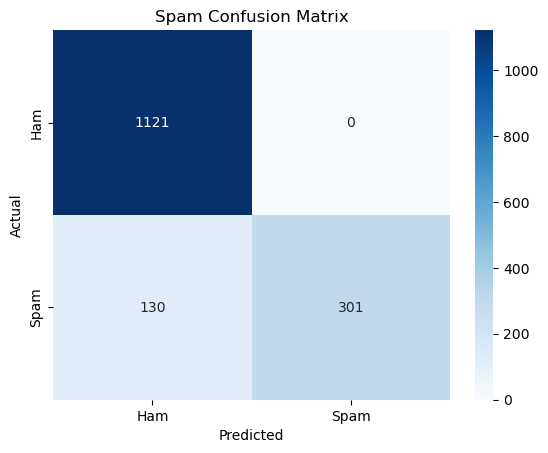

In [21]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predict test set
y_pred = nb.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam Confusion Matrix")
plt.show()

# Visualizes correct and incorrect spam/ham classifications

In [23]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(classification_report(y_test, y_pred))

# Precision → proportion of predicted spam that are actually spam
# Recall → proportion of actual spam correctly detected
# Accuracy → overall correctness

Accuracy: 0.92
Precision: 1.00
Recall: 0.70
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1121
           1       1.00      0.70      0.82       431

    accuracy                           0.92      1552
   macro avg       0.95      0.85      0.88      1552
weighted avg       0.92      0.92      0.91      1552



In [25]:
# Cross-validation
cv_scores = cross_val_score(nb, X, y, cv=5)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.2f}")

# Ensures model stability across different splits

CV Scores: [0.91111111 0.93230174 0.92843327 0.92166344 0.91489362]
Mean CV Accuracy: 0.92


In [27]:
# Predict probabilities for first 5 test messages
print(nb.predict_proba(X_test[:5]))

# Confidence of model in predicting ham vs spam

[[9.99790505e-01 2.09494966e-04]
 [2.20075521e-01 7.79924479e-01]
 [9.99998514e-01 1.48588305e-06]
 [9.99999886e-01 1.14285146e-07]
 [9.99999879e-01 1.21435114e-07]]
